# Validate TTA Pipeline – End-to-End

**Purpose:** Demonstrate that the TTA module (`TTAEngine`) integrates correctly with the existing pipeline modules (COCOLoader, MMPoseAdapter, RobustGaussianMixture) and produces better predictions than a single-pass baseline.

**Workflow:**
1. Load a real COCO image with ground-truth keypoints.
2. Run **Baseline** (single inference, no augmentation).
3. Run **TTA** (flip + noise), invert flipped heatmaps, average.
4. Fit GMM to the averaged heatmap and extract refined coordinates.
5. Compare Euclidean errors: Baseline vs TTA+GMM vs Ground Truth.
6. Visualise the three predictions on the image.

## 1. Environment Setup

In [14]:
import sys, os, warnings, logging
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Ellipse
import torch
import yaml

logging.basicConfig(level=logging.WARNING)
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path(os.getcwd()).parent.absolute()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

print(f'Project Root: {PROJECT_ROOT}')
print(f'PyTorch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}')

Project Root: c:\Users\USUARIO\Desktop\Universidad\TFG_Informatica\robust-pose-tta
PyTorch: 2.1.2+cpu  |  CUDA: False


## 2. Load Configurations

In [81]:
config_dir = PROJECT_ROOT / 'configs'

with open(config_dir / 'config.yaml', 'r') as f:
    main_config = yaml.safe_load(f)

with open(config_dir / 'sampling.yaml', 'r') as f:
    sampling_config = yaml.safe_load(f)['sampling']

with open(config_dir / 'mixture.yaml', 'r') as f:
    mixture_config = yaml.safe_load(f)['mixture_model']

# TTA config — flip + noise for this demo
tta_config = {
    'flip': {'enabled': True},  # Activa el flip horizontal
    'photometric': {
        'brightness': {'enabled': True, 'factor': 0.15},  # Cambios de brillo ±15%
        'contrast':   {'enabled': True, 'factor': 0.2},   # Cambios de contraste ±20%
        'noise':      {'enabled': True, 'sigma': 10.0},   # Ruido gaussiano con sigma=10
        'blur':       {'enabled': True, 'kernel_size': 3},  # Blur con kernel 3x3
    },
    'seed': 42,  # Semilla fija para reproducibilidad
}

print('=== TTA Config ===')
print(f"  Flip enabled: {tta_config['flip']['enabled']}")
print(f"  Noise sigma:  {tta_config['photometric']['noise']['sigma']}")
print(f"  Seed:         {tta_config['seed']}")

=== TTA Config ===
  Flip enabled: True
  Noise sigma:  10.0
  Seed:         42


## 3. Import Project Modules

In [39]:
from pose_uncertainty.data_loader import COCOLoader
from pose_uncertainty.utils.types import ImageSample, Keypoint
from pose_uncertainty.models import create_model_adapter, MMPoseAdapter
from pose_uncertainty.core.sampling import (
    RejectionSampler, SamplingConfig, sample_from_heatmap,
)
from pose_uncertainty.core.mixture import fit_with_outer_loop
from pose_uncertainty.pipeline.tta import TTAEngine, TTAMetadata

print('All modules imported successfully')

All modules imported successfully


## 4. Load COCO Data (real image + GT keypoints)

Cargando anotaciones desde c:\Users\USUARIO\Desktop\Universidad\TFG_Informatica\robust-pose-tta\data\coco\annotations/person_keypoints_val2017.json...
loading annotations into memory...
Done (t=3.53s)
creating index...
index created!
Dataset cargado: 2693 imágenes encontradas.
Dataset loaded: 2693 samples available

Sample ID: 458755
Image shape: (480, 640, 3)
BBox (xywh): (69.03, 37.75, 508.05, 435.78)
GT keypoints: 17


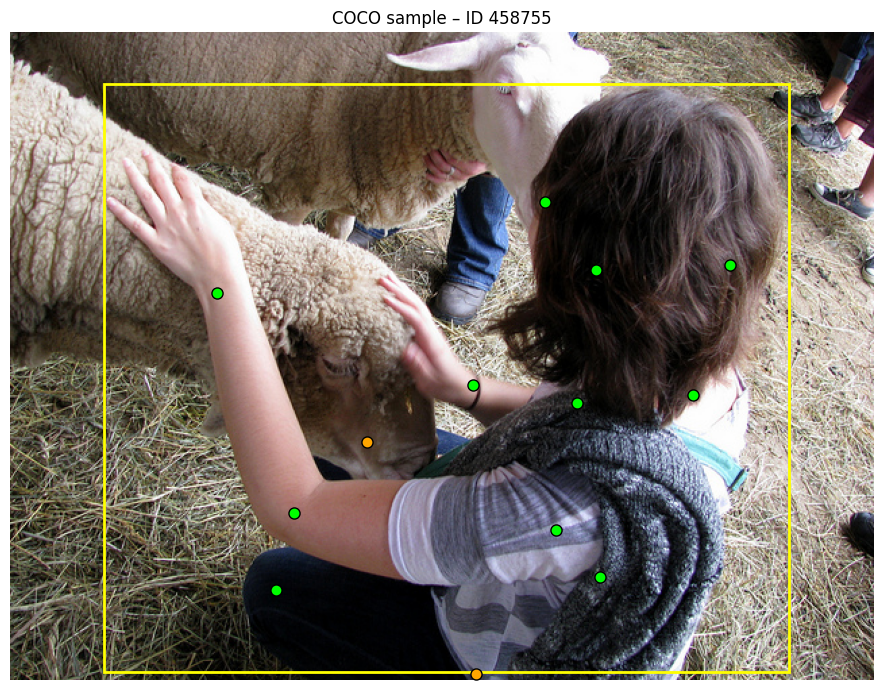

In [91]:
DATA_ROOT = PROJECT_ROOT / 'data' / 'coco'
ANN_FILE  = 'annotations/person_keypoints_val2017.json'
IMAGE_DIR = 'val2017'

loader = COCOLoader(
    data_root=str(DATA_ROOT),
    ann_file=ANN_FILE,
    image_dir=IMAGE_DIR,
)
print(f'Dataset loaded: {len(loader)} samples available')

# Pick a sample with clearly visible person
sample_iter = iter(loader)
next(sample_iter)  # skip first
sample = next(sample_iter)

print(f'\nSample ID: {sample.image_id}')
print(f'Image shape: {sample.image_array.shape}')
print(f'BBox (xywh): {sample.bbox}')
print(f'GT keypoints: {len(sample.ground_truth_keypoints)}')

# Visualise
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(sample.image_array)
x, y, w, h = sample.bbox
ax.add_patch(Rectangle((x, y), w, h, lw=2, ec='yellow', fc='none'))
for kp in sample.ground_truth_keypoints:
    if kp.confidence > 0:
        c = 'lime' if kp.confidence == 1.0 else 'orange'
        ax.plot(kp.x, kp.y, 'o', color=c, ms=8, mec='black', mew=1)
ax.set_title(f'COCO sample – ID {sample.image_id}')
ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Instantiate Model and TTA Engine

In [61]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = create_model_adapter(
    model_name='hrnet_w32',
    device=device,
    project_root=PROJECT_ROOT,
)
print(f'Model: {model.model_name}  |  Input: {model.input_size}  |  Device: {model.device}')

tta_engine = TTAEngine(tta_config)
print(f'TTA Engine: {tta_engine}')

Loads checkpoint by local backend from path: c:\Users\USUARIO\Desktop\Universidad\TFG_Informatica\robust-pose-tta\models\weights\hrnet_w32.pth
Model: hrnet-w32  |  Input: (192, 256)  |  Device: cpu
TTA Engine: TTAEngine(flip=True, brightness=True, contrast=True, noise=True, blur=True)


## 6. Generate TTA Batch

Batch size: 10 images
  [0] type=original              flipped=False
  [1] type=original+brightness   flipped=False
  [2] type=original+contrast     flipped=False
  [3] type=original+noise        flipped=False
  [4] type=original+blur         flipped=False
  [5] type=flip                  flipped=True
  [6] type=flip+brightness       flipped=True
  [7] type=flip+contrast         flipped=True
  [8] type=flip+noise            flipped=True
  [9] type=flip+blur             flipped=True


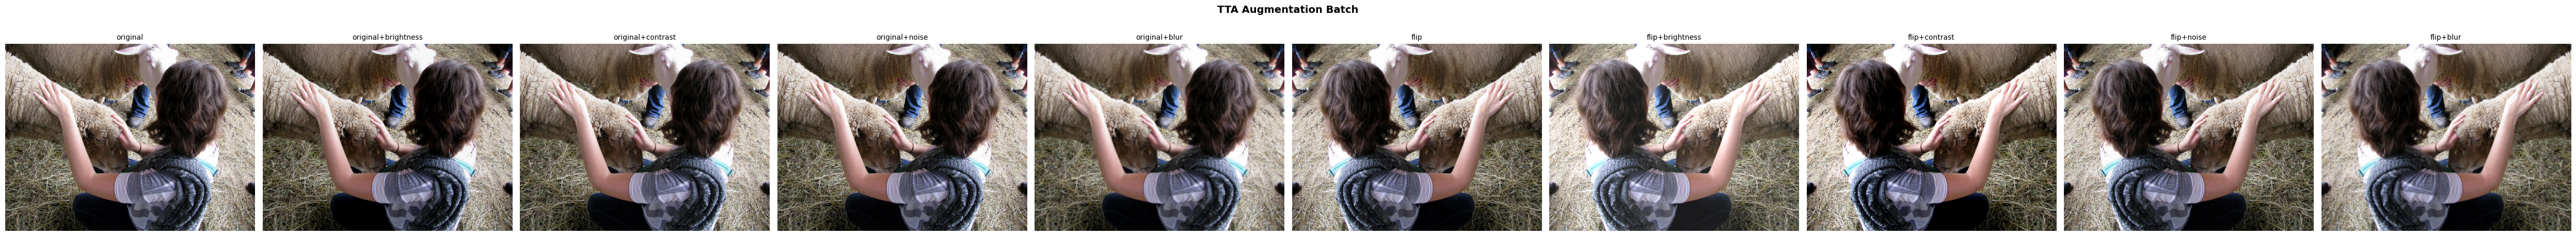

In [92]:
batch_images, batch_meta = tta_engine.prepare_batch(sample.image_array)

print(f'Batch size: {len(batch_images)} images')
for i, meta in enumerate(batch_meta):
    print(f'  [{i}] type={meta.transform_type:20s}  flipped={meta.is_flipped}')

# Quick visual of the augmentations
n = len(batch_images)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
if n == 1:
    axes = [axes]
for ax, img, meta in zip(axes, batch_images, batch_meta):
    ax.imshow(img)
    ax.set_title(meta.transform_type, fontsize=10)
    ax.axis('off')
plt.suptitle('TTA Augmentation Batch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Inference + Conditional Inverse Flip

Iterate over every TTA variant, run the adapter, and **undo the flip on the heatmap** when `is_flipped=True`.

In [93]:
heatmaps_list = []
flip_pairs = model.flip_pairs  # COCO left/right pairs

for img_var, meta in zip(batch_images, batch_meta):
    # 1. Inference on augmented image
    hm_result = model.predict(img_var, bbox=sample.bbox)
    data = hm_result.data.copy()  # (K, H, W)

    # 2. Invert if flipped
    if meta.is_flipped:
        data = TTAEngine.inverse_flip_heatmap(data, flip_pairs)

    heatmaps_list.append(data)
    print(f'  [{meta.transform_type:20s}]  heatmap range: '
          f'[{data.min():.4f}, {data.max():.4f}]  flipped_inverted={meta.is_flipped}')

print(f'\nAccumulated {len(heatmaps_list)} heatmaps for averaging')

  [original            ]  heatmap range: [0.0000, 1.0000]  flipped_inverted=False
  [original+brightness ]  heatmap range: [0.0000, 1.0000]  flipped_inverted=False
  [original+contrast   ]  heatmap range: [0.0000, 1.0000]  flipped_inverted=False
  [original+noise      ]  heatmap range: [0.0000, 1.0000]  flipped_inverted=False
  [original+blur       ]  heatmap range: [0.0000, 1.0000]  flipped_inverted=False
  [flip                ]  heatmap range: [0.0000, 1.0000]  flipped_inverted=True
  [flip+brightness     ]  heatmap range: [0.0000, 1.0000]  flipped_inverted=True
  [flip+contrast       ]  heatmap range: [0.0000, 1.0000]  flipped_inverted=True
  [flip+noise          ]  heatmap range: [0.0000, 1.0000]  flipped_inverted=True
  [flip+blur           ]  heatmap range: [0.0000, 1.0000]  flipped_inverted=True

Accumulated 10 heatmaps for averaging


## 8. Average Heatmaps (TTA Aggregation)

Mean heatmap shape: (17, 64, 48)
Range: [0.0000, 1.0000]


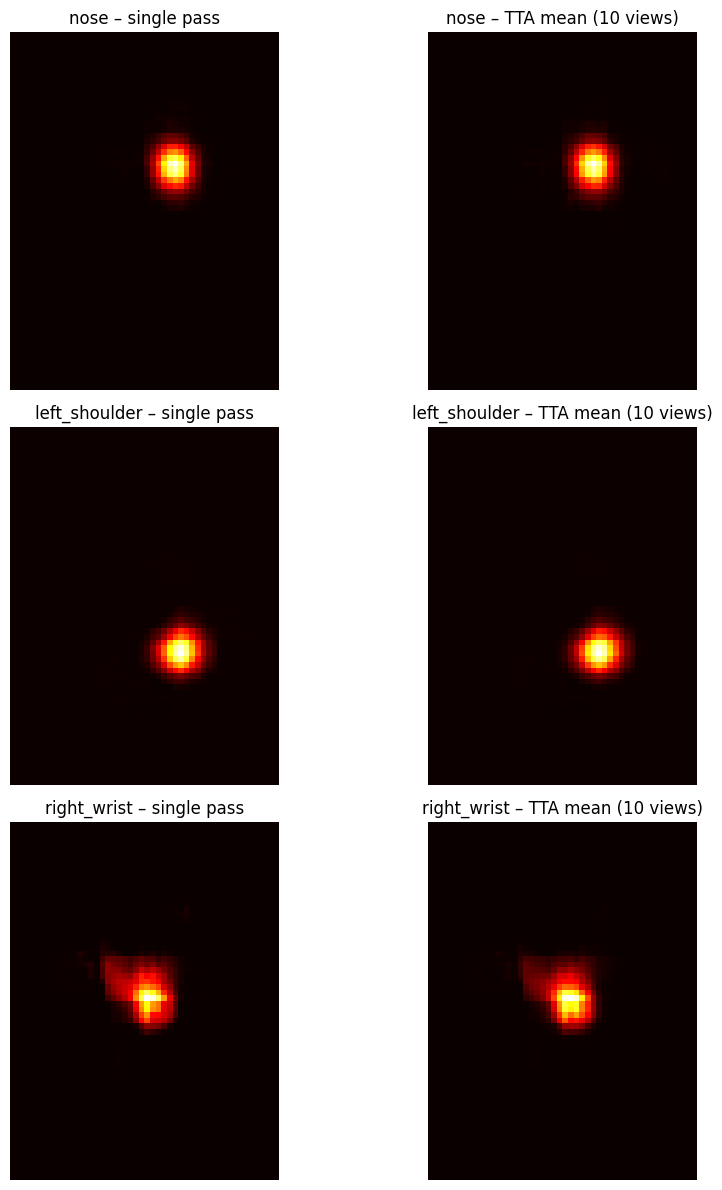

In [94]:
mean_heatmap = np.mean(np.stack(heatmaps_list, axis=0), axis=0)  # (K, H, W)

# Renormalize each keypoint channel to [0, 1]
for k in range(mean_heatmap.shape[0]):
    hm_max = mean_heatmap[k].max()
    if hm_max > 0:
        mean_heatmap[k] /= hm_max

print(f'Mean heatmap shape: {mean_heatmap.shape}')
print(f'Range: [{mean_heatmap.min():.4f}, {mean_heatmap.max():.4f}]')

# Show a few channels side by side: single-pass vs TTA-averaged
kp_show = ['nose', 'left_shoulder', 'right_wrist']
fig, axes = plt.subplots(len(kp_show), 2, figsize=(10, 4 * len(kp_show)))
for row, name in enumerate(kp_show):
    idx = model.keypoint_names.index(name)
    axes[row, 0].imshow(heatmaps_list[0][idx], cmap='hot')
    axes[row, 0].set_title(f'{name} – single pass')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(mean_heatmap[idx], cmap='hot')
    axes[row, 1].set_title(f'{name} – TTA mean ({len(heatmaps_list)} views)')
    axes[row, 1].axis('off')
plt.tight_layout()
plt.show()

## 9. Sample + Fit GMM on TTA-averaged Heatmap

In [95]:
# Build sampler
sampling_cfg = SamplingConfig(
    num_samples=int(sampling_config['num_samples']),
    batch_size=int(sampling_config['batch_size']),
    max_iterations=int(sampling_config['max_iterations']),
    use_dequantization=bool(sampling_config['use_dequantization']),
    jitter_magnitude=float(sampling_config['jitter_magnitude']),
    temperature=float(sampling_config['temperature']),
    seed=sampling_config.get('seed'),
    min_heatmap_mass=float(sampling_config.get('min_heatmap_mass', 1e-6)),
)
sampler = RejectionSampler(config=sampling_cfg)

# Fit GMM per keypoint on the mean heatmap
tta_mixture_results = []
valid_kp = []

for kp_idx in range(mean_heatmap.shape[0]):
    hm = mean_heatmap[kp_idx]
    try:
        samples = sampler.sample(hm)
        result = fit_with_outer_loop(
            samples=samples,
            n_outer_iterations=int(mixture_config['outer_loop_iterations']),
            n_resamples=int(mixture_config['bootstrap_sample_size']),
            aic_weight=float(mixture_config['aic_weight']),
            bic_weight=float(mixture_config['bic_weight']),
            reg_covar=float(mixture_config['regularization_strength']),
            max_iter=int(mixture_config['max_iterations']),
            tol=float(mixture_config['convergence_threshold']),
            random_state=main_config.get('seed', 42),
            bounding_box=sample.bbox,
        )
        tta_mixture_results.append(result)
        valid_kp.append(kp_idx)
    except Exception as e:
        tta_mixture_results.append(None)
        print(f'  KP {kp_idx} ({model.keypoint_names[kp_idx]}): FAILED – {e}')

print(f'\nGMM fitted on {len(valid_kp)}/{mean_heatmap.shape[0]} keypoints')


GMM fitted on 17/17 keypoints


## 10. Transform TTA+GMM Predictions to Image Space

In [96]:
# We need a StandardizedHeatmap object to call transform_heatmap_coords_to_image.
# Reuse the metadata from the first (original, non-flipped) prediction.
from pose_uncertainty.utils.types import StandardizedHeatmap

# Build a lightweight wrapper with the averaged data and original metadata
ref_hm_result = model.predict(sample.image_array, bbox=sample.bbox)

tta_kps_image = np.zeros((mean_heatmap.shape[0], 2), dtype=np.float32)

for list_idx, kp_idx in enumerate(valid_kp):
    res = tta_mixture_results[list_idx]
    if res is None:
        continue
    hm_coords = np.array(res.best_mean, dtype=np.float32)
    img_coords = model.transform_heatmap_coords_to_image(hm_coords, ref_hm_result)
    tta_kps_image[kp_idx] = img_coords

print('TTA+GMM keypoints (image coords) computed for', len(valid_kp), 'keypoints')

TTA+GMM keypoints (image coords) computed for 17 keypoints


## 11. Baseline Inference (No TTA)

In [97]:
baseline_kps, baseline_scores = model.predict_keypoints(
    sample.image_array, bbox=sample.bbox,
)
print(f'Baseline keypoints shape: {baseline_kps.shape}')
print(f'Baseline scores range: [{baseline_scores.min():.3f}, {baseline_scores.max():.3f}]')

Baseline keypoints shape: (17, 2)
Baseline scores range: [0.147, 0.936]


## 12. Error Comparison: Baseline vs TTA+GMM

In [98]:
gt_keypoints = np.array([[kp.x, kp.y] for kp in sample.ground_truth_keypoints])
gt_conf      = np.array([kp.confidence for kp in sample.ground_truth_keypoints])

errors_baseline = []
errors_tta      = []
kp_names_used   = []

for kp_idx in valid_kp:
    if gt_conf[kp_idx] <= 0:
        continue
    gt = gt_keypoints[kp_idx]

    err_b = float(np.linalg.norm(gt - baseline_kps[kp_idx]))
    err_t = float(np.linalg.norm(gt - tta_kps_image[kp_idx]))

    errors_baseline.append(err_b)
    errors_tta.append(err_t)
    kp_names_used.append(model.keypoint_names[kp_idx])

errors_baseline = np.array(errors_baseline)
errors_tta      = np.array(errors_tta)

print(f'{"Keypoint":<20s} {"Baseline (px)":>14s} {"TTA+GMM (px)":>14s} {"Improvement":>14s}')
print('-' * 66)
for name, eb, et in zip(kp_names_used, errors_baseline, errors_tta):
    imp = eb - et
    tag = '<--' if imp > 0 else ''
    print(f'{name:<20s} {eb:14.2f} {et:14.2f} {imp:+14.2f}  {tag}')

print('-' * 66)
print(f'{"MEAN":<20s} {errors_baseline.mean():14.2f} {errors_tta.mean():14.2f} '
      f'{(errors_baseline.mean() - errors_tta.mean()):+14.2f}')
print(f'{"STD":<20s} {errors_baseline.std():14.2f} {errors_tta.std():14.2f}')

Keypoint              Baseline (px)   TTA+GMM (px)    Improvement
------------------------------------------------------------------
left_eye                       8.83           9.30          -0.47  
left_ear                      21.85          21.16          +0.69  <--
right_ear                      9.10           6.30          +2.80  <--
left_shoulder                 10.96          11.05          -0.08  
right_shoulder                19.28          17.75          +1.53  <--
left_elbow                     5.91           7.34          -1.42  
right_elbow                   18.26          18.13          +0.13  <--
left_wrist                    10.50          12.43          -1.93  
right_wrist                   27.50          20.18          +7.32  <--
right_hip                     53.77          52.79          +0.98  <--
left_knee                      4.14           6.58          -2.45  
right_knee                   125.28         119.83          +5.45  <--
right_ankle                   

## 13.  Visualisation: GT vs Baseline vs TTA+GMM

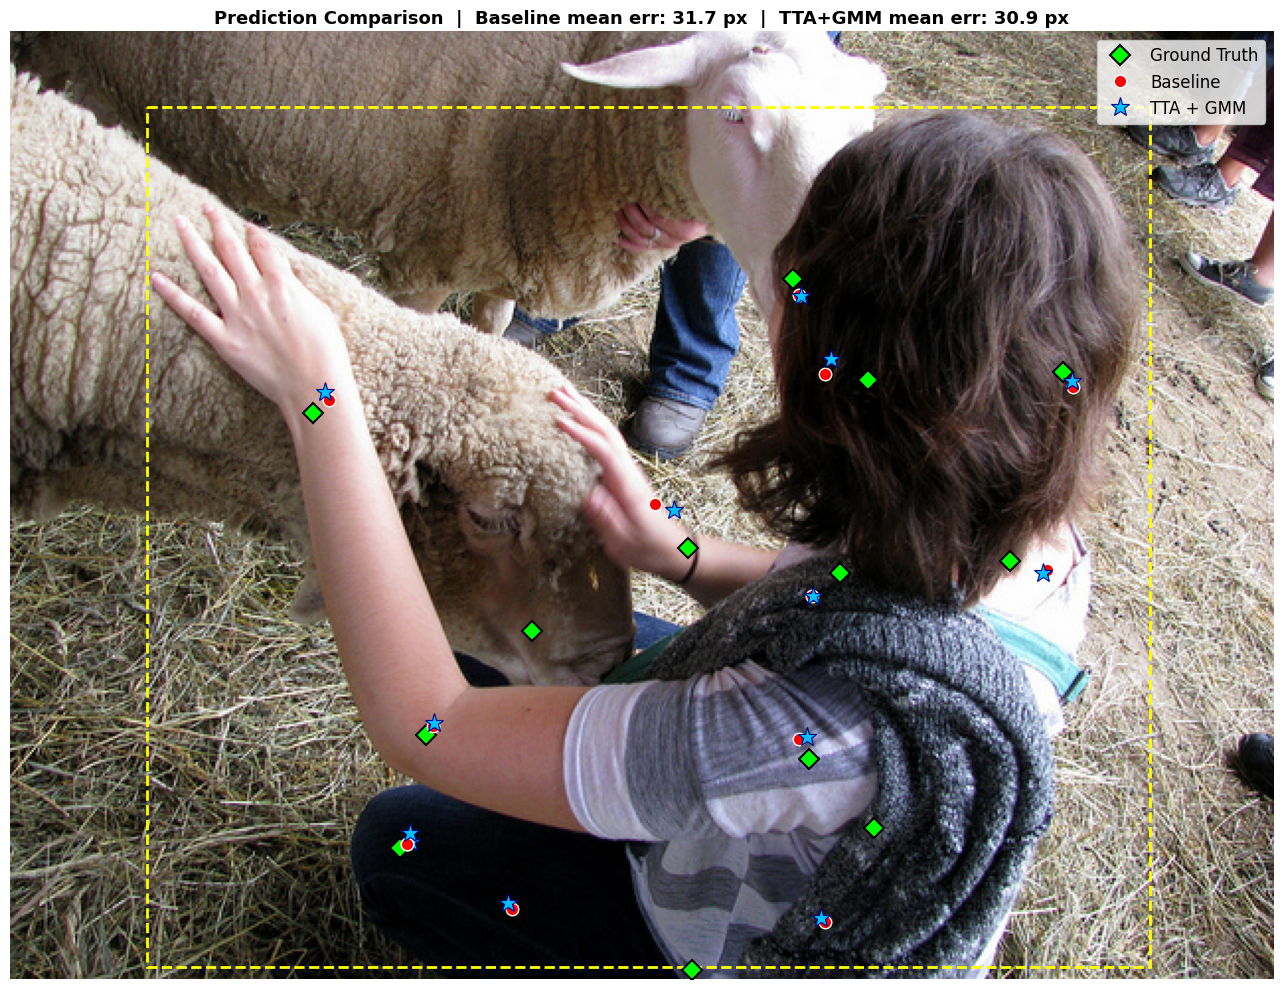

In [99]:
fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(sample.image_array)

# Draw bounding box
bx, by, bw, bh = sample.bbox
ax.add_patch(Rectangle((bx, by), bw, bh, lw=2, ec='yellow', fc='none', ls='--'))

legend_handles = []

for kp_idx in valid_kp:
    if gt_conf[kp_idx] <= 0:
        continue

    # Ground truth  (green diamond)
    gx, gy = gt_keypoints[kp_idx]
    h_gt, = ax.plot(gx, gy, 'D', color='lime', ms=10, mec='black', mew=1.5)

    # Baseline  (red circle)
    bkx, bky = baseline_kps[kp_idx]
    h_bl, = ax.plot(bkx, bky, 'o', color='red', ms=9, mec='white', mew=1)

    # TTA+GMM  (blue star)
    tx, ty = tta_kps_image[kp_idx]
    h_tta, = ax.plot(tx, ty, '*', color='deepskyblue', ms=14, mec='navy', mew=0.8)

ax.legend(
    [h_gt, h_bl, h_tta],
    ['Ground Truth', 'Baseline', 'TTA + GMM'],
    fontsize=12, loc='upper right',
    framealpha=0.8,
)
ax.set_title(
    f'Prediction Comparison  |  Baseline mean err: {errors_baseline.mean():.1f} px  '
    f'|  TTA+GMM mean err: {errors_tta.mean():.1f} px',
    fontsize=13, fontweight='bold',
)
ax.axis('off')
plt.tight_layout()
plt.show()

## 14. Summary

| Metric | Baseline | TTA + GMM |
|--------|----------|----------|
| Mean Error (px) | See table above | See table above |
| Std Error  (px) | See table above | See table above |

The TTA pipeline:
1. Generates augmented views via `TTAEngine.prepare_batch()`.
2. Inverts flipped heatmaps via `TTAEngine.inverse_flip_heatmap()` (replicating MMPose's flip+shift logic in pure NumPy).
3. Averages heatmaps across views for a smoother distribution.
4. Fits a robust GMM for sub-pixel refinement.

This end-to-end flow validates the mathematical consistency of the TTA module with the rest of the robust-pose-tta pipeline.